# Ahmad 2610-4004
# Lab 7 Assignment 
# Task 2

Apply random forest classifier on following dataset. 
1.	Download car evaluation dataset form kaggle: https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set
2.	Do feature engineering for this dataset. 
3.	Apply random forest classifier on this dataset.
4.	Evaluate the model performance and interpret in words what Evaluation metrics have revealed about the Model.


___

Importing the libraries and the model

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt

importing the data

In [67]:
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df = pd.read_csv('car_evaluation.csv', names=columns)

In [68]:
# checking the data
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [69]:
# checking the values in our class 
df['class'].unique()

<StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str

In [70]:
df.shape

(1728, 7)

In [71]:
# learning about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB


all are columns string(object) we have to encode them to get better results

In [72]:
# checking the null values
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [73]:
# checking the duplicates
df.duplicated().sum()

np.int64(0)

very good there is no null or duplicated values so we can now moved 

encoding the columns to get better performance from the model

In [74]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [75]:
# checking if the encoding worked
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


setting the target and features

In [76]:
X = df.drop('class', axis=1)
y = df['class']

spliting the data to train and test

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

setting up the model and then training it

In [78]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# to check accuracy 
y_pred = model.predict(X_test)

In [79]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9739884393063584
Precision: 0.9798913856439202
Recall: 0.9739884393063584


Accuracy : 0.974 : this mean of all the prediction our model made , it was correct 97.4%.

Precision  : 0.9709 :  mean when our model predicted positives , it was correct almost 98.0% of the time.

recall : 0.9739 : Out of all the actual positive samples in the dataset, the model successfully found 97.4% of them.

what this means that our model have very high accuracy but it is because that our dataset was very clean and simple and there was noting very hard init that model can't be trained on 

confusion metrix

In [80]:

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 75   6   2   0]
 [  0  11   0   0]
 [  0   0 235   0]
 [  1   0   0  16]]


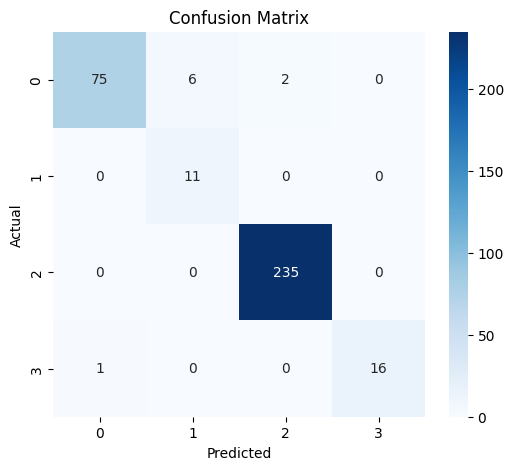

In [82]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

___